# Feature Scaling - Normalization

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("wine.csv",usecols=[x for x in range(3)])
# df.columns=['Class label','Alcohol','Malic Acid']

In [17]:
df

,Wine,Alcohol,Malic.acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

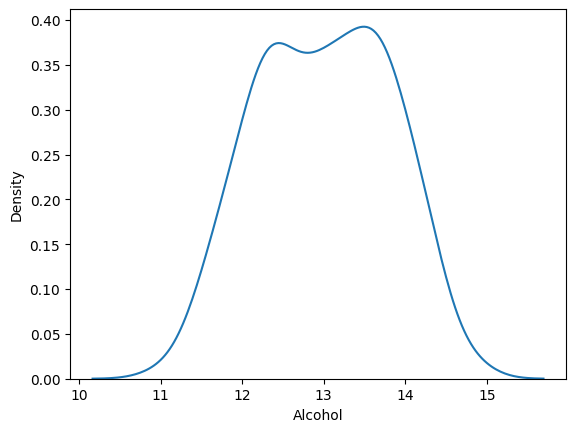

In [18]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic.acid', ylabel='Density'>

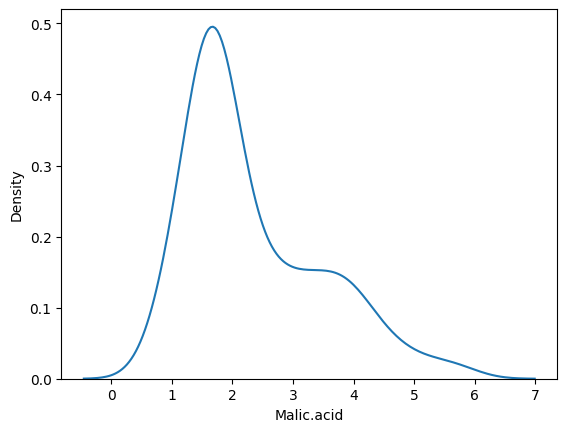

In [20]:
sns.kdeplot(df['Malic.acid'])

<Axes: xlabel='Alcohol', ylabel='Malic.acid'>

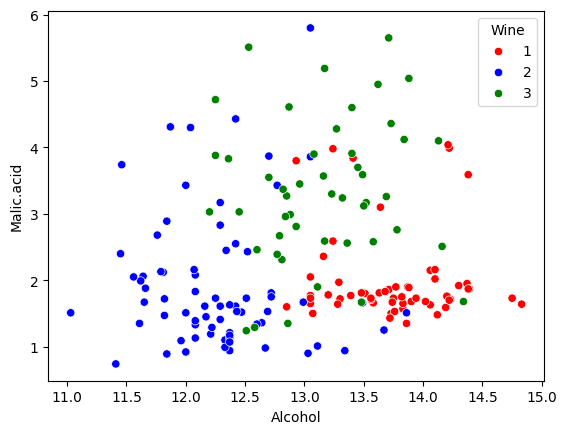

In [23]:
color_dict={1:'red',3:'green',2:'blue'}
# sns.scatterplot(df['Alcohol'],df['Malic.acid'],hue=df['Wine'],palette=color_dict)
sns.scatterplot(
    x=df['Alcohol'],
    y=df['Malic.acid'],
    hue=df['Wine'],
    palette=color_dict
)

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop("Wine",axis=1),df['Wine'],test_size=0.3,random_state=0)
x_train.shape,x_test.shape

((124, 2), (54, 2))

In [26]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#Fit the scaler to the train set , it will learn the parameters
scaler.fit(x_train)

#transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [27]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [28]:
x_train.describe()

,Alcohol,Malic.acid
count,124.000000,124.000000
mean,12.983065,2.383710
std,0.801340,1.136696
min,11.030000,0.890000
25%,12.362500,1.607500
50%,13.040000,1.885000
75%,13.640000,3.247500
max,14.750000,5.650000


In [30]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic.acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


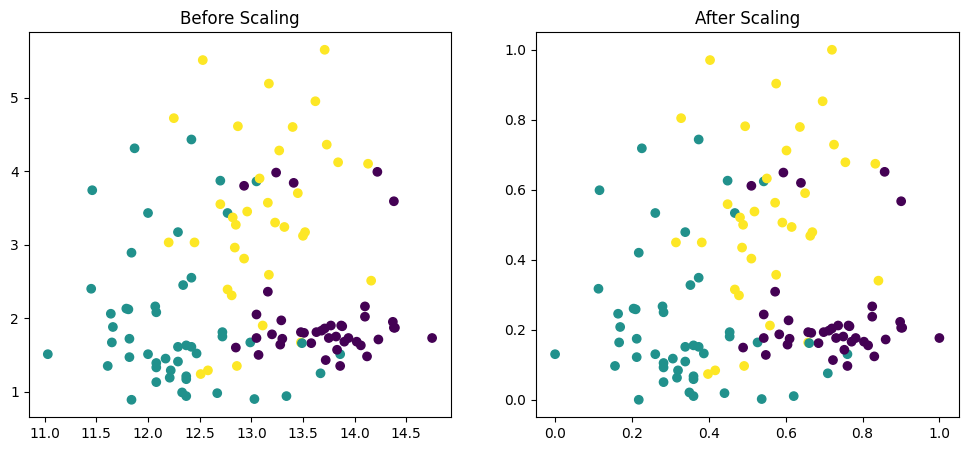

In [36]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['Alcohol'],x_train['Malic.acid'],c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(x_train_scaled['Alcohol'],x_train_scaled['Malic.acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

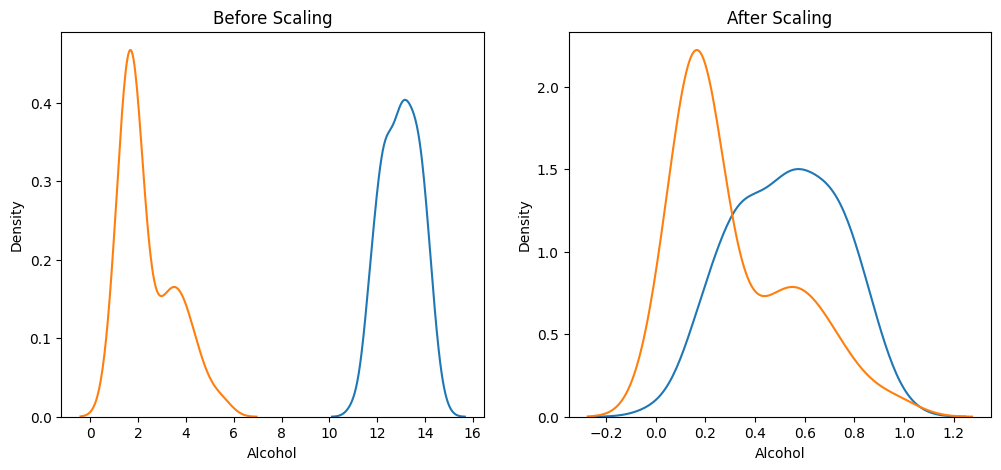

In [37]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize = (12,5))
#Before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Alcohol'],ax=ax1)
sns.kdeplot(x_train['Malic.acid'],ax=ax1)
ax2.set_title('After Scaling')
sns.kdeplot(x_train_scaled['Alcohol'],ax=ax2)
sns.kdeplot(x_train_scaled['Malic.acid'],ax=ax2)
plt.show()

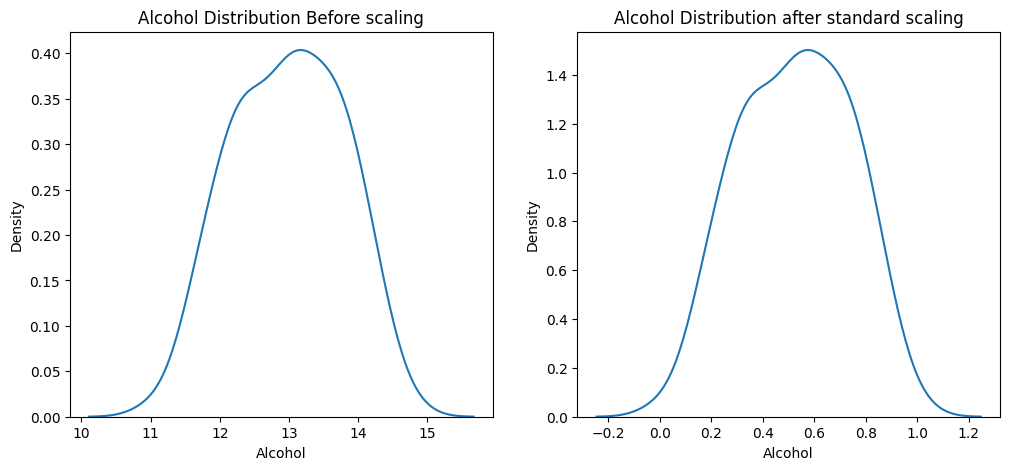

In [39]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
# Before Scaling 
ax1.set_title('Alcohol Distribution Before scaling')
sns.kdeplot(x_train['Alcohol'],ax=ax1)

# After Scaling
ax2.set_title('Alcohol Distribution after standard scaling')
sns.kdeplot(x_train_scaled['Alcohol'],ax=ax2)
plt.show()

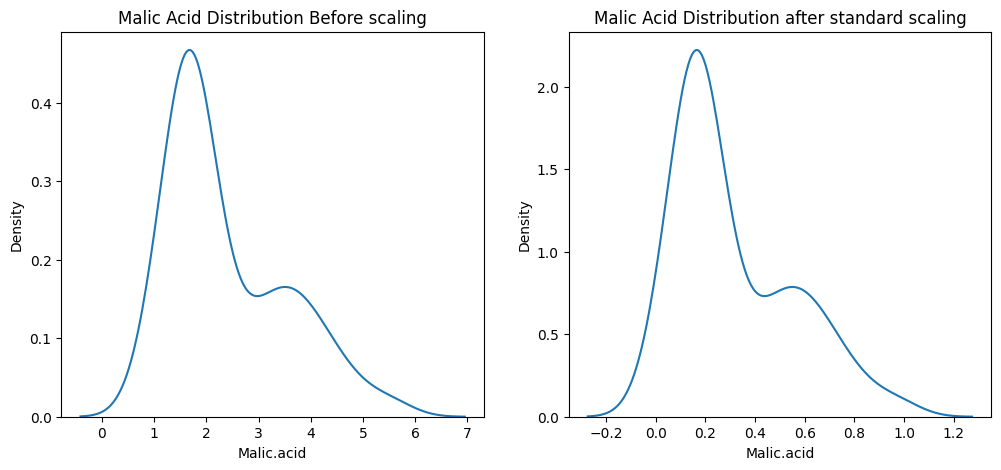

In [40]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
# Before Scaling 
ax1.set_title('Malic Acid Distribution Before scaling')
sns.kdeplot(x_train['Malic.acid'],ax=ax1)

# After Scaling
ax2.set_title('Malic Acid Distribution after standard scaling')
sns.kdeplot(x_train_scaled['Malic.acid'],ax=ax2)
plt.show()